In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl

graphs_dir = "results3/graphs"
os.makedirs("../"+graphs_dir, exist_ok=True)
os.makedirs("../"+graphs_dir+"/means", exist_ok=True)

stats_dir = "results3/stats"
os.makedirs("../"+stats_dir, exist_ok=True)

noises = [0] + [round(i*0.01, 2) for i in range(1, 11)]
tests = ['testAB', 'testAG', 'test']


In [2]:
methods_lst = ['aligns', 'grad01_avg', 'grad01_max', 'gradient_conf_avg', 
               'gradient_conf_max', 'gradient_input_avg', 'gradient_input_max', 
               'hamming_max', 'hamming_min', 'model_grad_avg', 'model_grad_max', 
               'qbc', 'threshold_avg', 'threshold_max', 'random', 'feature_cosine', 'feature_eucl']

base_palette = [
    "#000000", "#004949", "#009292", "#ff6db6", "#ffb6db",
    "#490092", "#006ddb", "#b66dff", "#6db6ff", "#b6dbff",
    "#920000", "#924900", "#db6d00", "#24ff24", "#ffff6d", "#ff0000", "#ffa500"
]

user_palette = {methods_lst[i]: base_palette[i] for i in range(len(methods_lst))}
method_colors = dict(user_palette)

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

try:
    cmap = mpl.colormaps.get_cmap("tab20")
except AttributeError:
    cmap = plt.get_cmap("tab20")

if hasattr(cmap, "colors"):
    base_colors = list(cmap.colors)
else:
    N = getattr(cmap, "N", 20)
    base_colors = [cmap(i / max(N - 1, 1)) for i in range(N)]

all_methods = methods_lst
missing = [m for m in all_methods if m not in method_colors]
for i, method in enumerate(missing):
    rgba = base_colors[i % len(base_colors)]
    method_colors[method] = mcolors.to_hex(rgba)

method_labels = {m: m.replace('_', ' ') for m in methods_lst}


# noise split

In [3]:
METHOD_RE = re.compile(r"roc_aucs_(.+?)_(\d+)\.(tsv|csv)$")

out_base = os.path.join("..", graphs_dir)
os.makedirs(out_base, exist_ok=True)
os.makedirs(os.path.join(out_base, "means"), exist_ok=True)

def get_cmap_colors(name="tab20", min_len=20):
    try:
        cmap = mpl.colormaps.get_cmap(name)
    except Exception:
        cmap = plt.get_cmap(name)
    if hasattr(cmap, "colors"):
        colors = list(cmap.colors)
    else:
        N = getattr(cmap, "N", min_len)
        colors = [cmap(i / max(N - 1, 1)) for i in range(N)]
    return [mcolors.to_hex(c) for c in colors]

df_full = {}
for noise in noises:
    print(f"\n--- processing noise={noise} ---")
    base_dir = f"../results_small_final//noise{noise}"
    runs = [f"rand{i}" for i in range(100)]

    method_dfs = {}

    if not os.path.isdir(base_dir):
        print(f"Warning: base_dir {base_dir} not found — skipping noise={noise}")
        continue

    for run in runs:
        path = os.path.join(base_dir, run)
        if not os.path.exists(path):
            continue
        for file in os.listdir(path):
            if not file.startswith("roc_aucs_"):
                continue

            m = METHOD_RE.match(file)
            if m:
                method = m.group(1)
                ext = m.group(3)
            else:
                method = file.replace("roc_aucs_", "").rsplit(".", 1)[0]
                ext = file.rsplit(".", 1)[-1] if "." in file else "tsv"

            filepath = os.path.join(path, file)
            sep = "\t" if ext == "tsv" else ","
            try:
                df = pd.read_csv(filepath, sep=sep)
            except Exception as e:
                print(f"Warning: could not read {filepath}: {e}")
                continue

            if "ags_number" in df.columns:
                df["ags_number"] = pd.to_numeric(df["ags_number"], errors="coerce").astype("Int64")
            else:
                print(f"Warning: 'ags_number' not in {filepath}; skipping")
                continue

            df = df.assign(run_id=run)
            method_dfs.setdefault(method, []).append(df)

    if not method_dfs:
        print(f"No roc_aucs files found for noise={noise} under {base_dir}")
        continue

    if methods_lst:
        all_methods = [m for m in methods_lst if m in method_dfs]
        extras = sorted([m for m in method_dfs.keys() if m not in all_methods])
        all_methods += extras
    else:
        all_methods = sorted(method_dfs.keys())

    missing = [m for m in all_methods if m not in method_colors]
    if missing:
        base_colors = get_cmap_colors("tab20", min_len=max(20, len(missing)))
        for i, mm in enumerate(missing):
            method_colors[mm] = base_colors[i % len(base_colors)]

    for m in all_methods:
        method_labels.setdefault(m, m)

        import numpy as np 
    
   
    for test in tests:
        col = f"roc_aucs_{test}"

        means_export = {}
    
        for method in all_methods:
            dfs = method_dfs.get(method, [])
            if not dfs:
                continue
    
            try:
                df_all = pd.concat(dfs, ignore_index=True)
            except Exception as e:
                print(f"Warning: concat failed for method={method} at noise={noise}: {e}")
                continue
    
            if col not in df_all.columns:
                continue
    
            # группируем по ags_number и считаем статистики
            grouped = df_all.groupby("ags_number")[col]
            mean_series = grouped.mean().sort_index()
            if mean_series.empty:
                continue
            std_series = grouped.std().sort_index().reindex(mean_series.index).fillna(0.0)
            count_series = grouped.count().sort_index().reindex(mean_series.index).fillna(0).astype(int)
    

    dfq2_lst = []
    for m in all_methods:
        dfs = method_dfs.get(m, [])
        if not dfs:
            continue
        dfq2 = pd.concat(dfs, ignore_index=True)
        
        keep_cols = [c for c in ['iter', 'roc_auc_val', 'roc_aucs_test', 'roc_aucs_testAB',
                                  'roc_aucs_testAG', 'ags_number', 'run_id'] if c in dfq2.columns]
        dfq2 = dfq2[keep_cols].drop_duplicates().reset_index(drop=True)
        dfq2['method'] = m
        dfq2_lst.append(dfq2)

    if dfq2_lst:
        dfw = pd.concat(dfq2_lst, ignore_index=True)
    else:
        dfw = pd.DataFrame(columns=['iter', 'roc_auc_val', 'roc_aucs_test', 'roc_aucs_testAB',
                                    'roc_aucs_testAG', 'ags_number', 'run_id', 'method'])

    df_full[noise] = dfw
    print(f"Collected dfw for noise={noise}, shape={dfw.shape}")



--- processing noise=0 ---
Collected dfw for noise=0, shape=(151300, 8)

--- processing noise=0.01 ---
Collected dfw for noise=0.01, shape=(151300, 8)

--- processing noise=0.02 ---
Collected dfw for noise=0.02, shape=(151300, 8)

--- processing noise=0.03 ---
Collected dfw for noise=0.03, shape=(151300, 8)

--- processing noise=0.04 ---
Collected dfw for noise=0.04, shape=(151300, 8)

--- processing noise=0.05 ---
Collected dfw for noise=0.05, shape=(151300, 8)

--- processing noise=0.06 ---
Collected dfw for noise=0.06, shape=(106800, 8)

--- processing noise=0.07 ---
Collected dfw for noise=0.07, shape=(106800, 8)

--- processing noise=0.08 ---
Collected dfw for noise=0.08, shape=(151300, 8)

--- processing noise=0.09 ---
Collected dfw for noise=0.09, shape=(151300, 8)

--- processing noise=0.1 ---
Collected dfw for noise=0.1, shape=(151300, 8)


# noise mix

In [4]:
# # === ОБЪЕДИНЁННЫЙ POOLED ГРАФИК (все записи вместе) ===
# import numpy as np

# # Список dataframes (игнорируем пустые)
# all_dfs = [df.assign(noise=int(noise)) for noise, df in df_full.items() if not df.empty]
# if not all_dfs:
#     print("No data collected across noises — skipping pooled plots")
# else:
#     df_all_noises = pd.concat(all_dfs, ignore_index=True)

#     for test in tests:
#         col = f"roc_aucs_{test}"
#         if col not in df_all_noises.columns:
#             print(f"Column {col} not in pooled dataframe — skipping")
#             continue

#         plt.figure(figsize=(12, 20))
#         ax = plt.gca()
#         plotted_any = False
#         means_export = {}

#         # список всех методов в df_all_noises (чтобы не полагаться только на all_methods)
#         pool_methods = sorted(df_all_noises['method'].unique())

#         for method in pool_methods:
#             df_m = df_all_noises[df_all_noises['method'] == method]
#             if df_m.empty:
#                 continue

#             grouped = df_m.groupby("ags_number")[col]
#             mean_series = grouped.mean().sort_index()
#             if mean_series.empty:
#                 continue
#             std_series = grouped.std().sort_index().reindex(mean_series.index).fillna(0.0)
#             count_series = grouped.count().sort_index().reindex(mean_series.index).fillna(0).astype(int)

#             # 95% CI аналогично seaborn: mean +/- 1.96 * sem
#             sem = std_series / np.sqrt(count_series.replace(0, np.nan))
#             ci95 = 1.96 * sem
#             ribbon_low = (mean_series - ci95).values
#             ribbon_high = (mean_series + ci95).values
#             ribbon_low = np.where(np.isnan(ribbon_low), mean_series.values, ribbon_low)
#             ribbon_high = np.where(np.isnan(ribbon_high), mean_series.values, ribbon_high)
#             ribbon_low = np.clip(ribbon_low, 0.0, 1.0)
#             ribbon_high = np.clip(ribbon_high, 0.0, 1.0)

#             x = mean_series.index.astype(int).values
#             y = mean_series.values

#             color = method_colors.get(method, "#000000")
#             label = method_labels.get(method, method)

#             ax.plot(x, y, label=label, color=color, linewidth=2.5, marker=None, linestyle='-')
#             if len(x) == len(ribbon_low) == len(ribbon_high):
#                 ax.fill_between(x, ribbon_low, ribbon_high, color=color, alpha=0.18, linewidth=0)

#             means_export[method] = pd.Series(data=y, index=x)
#             plotted_any = True

#         if not plotted_any:
#             print(f"No pooled data for test={test}")
#             plt.close()
#             continue

#         k = 2
#         ax.set_xlabel("Number of antigens", fontsize=16*k)
#         ax.set_ylabel("ROC AUC", fontsize=16*k)
#         ax.set_title(f"{test}", fontsize=20*k)
#         ax.tick_params(axis='both', which='major', labelsize=14*k)
#         ax.set_frame_on(False)
#         ax.set_ylim(0.6, 1.0)
#         # ax.legend(loc='lower right', fontsize=10*k, frameon=False)

#         out_png = os.path.join(out_base, f"roc_auc_vs_ags_{test}_all_noises_pooled.png")
#         plt.tight_layout()
#         plt.savefig(out_png, dpi=150)
#         print(f"Saved pooled plot: {out_png}")
#         plt.show()
#         plt.close()

#         df_means = pd.DataFrame(means_export).sort_index()
#         out_csv = os.path.join(out_base, "means", f"mean_rocaucs_{test}_all_noises_pooled.csv")
#         df_means.to_csv(out_csv, index_label="ags_number")


Saved pooled plot: ../results3/graphs/roc_auc_vs_ags_testAB_all_noises_pooled.png


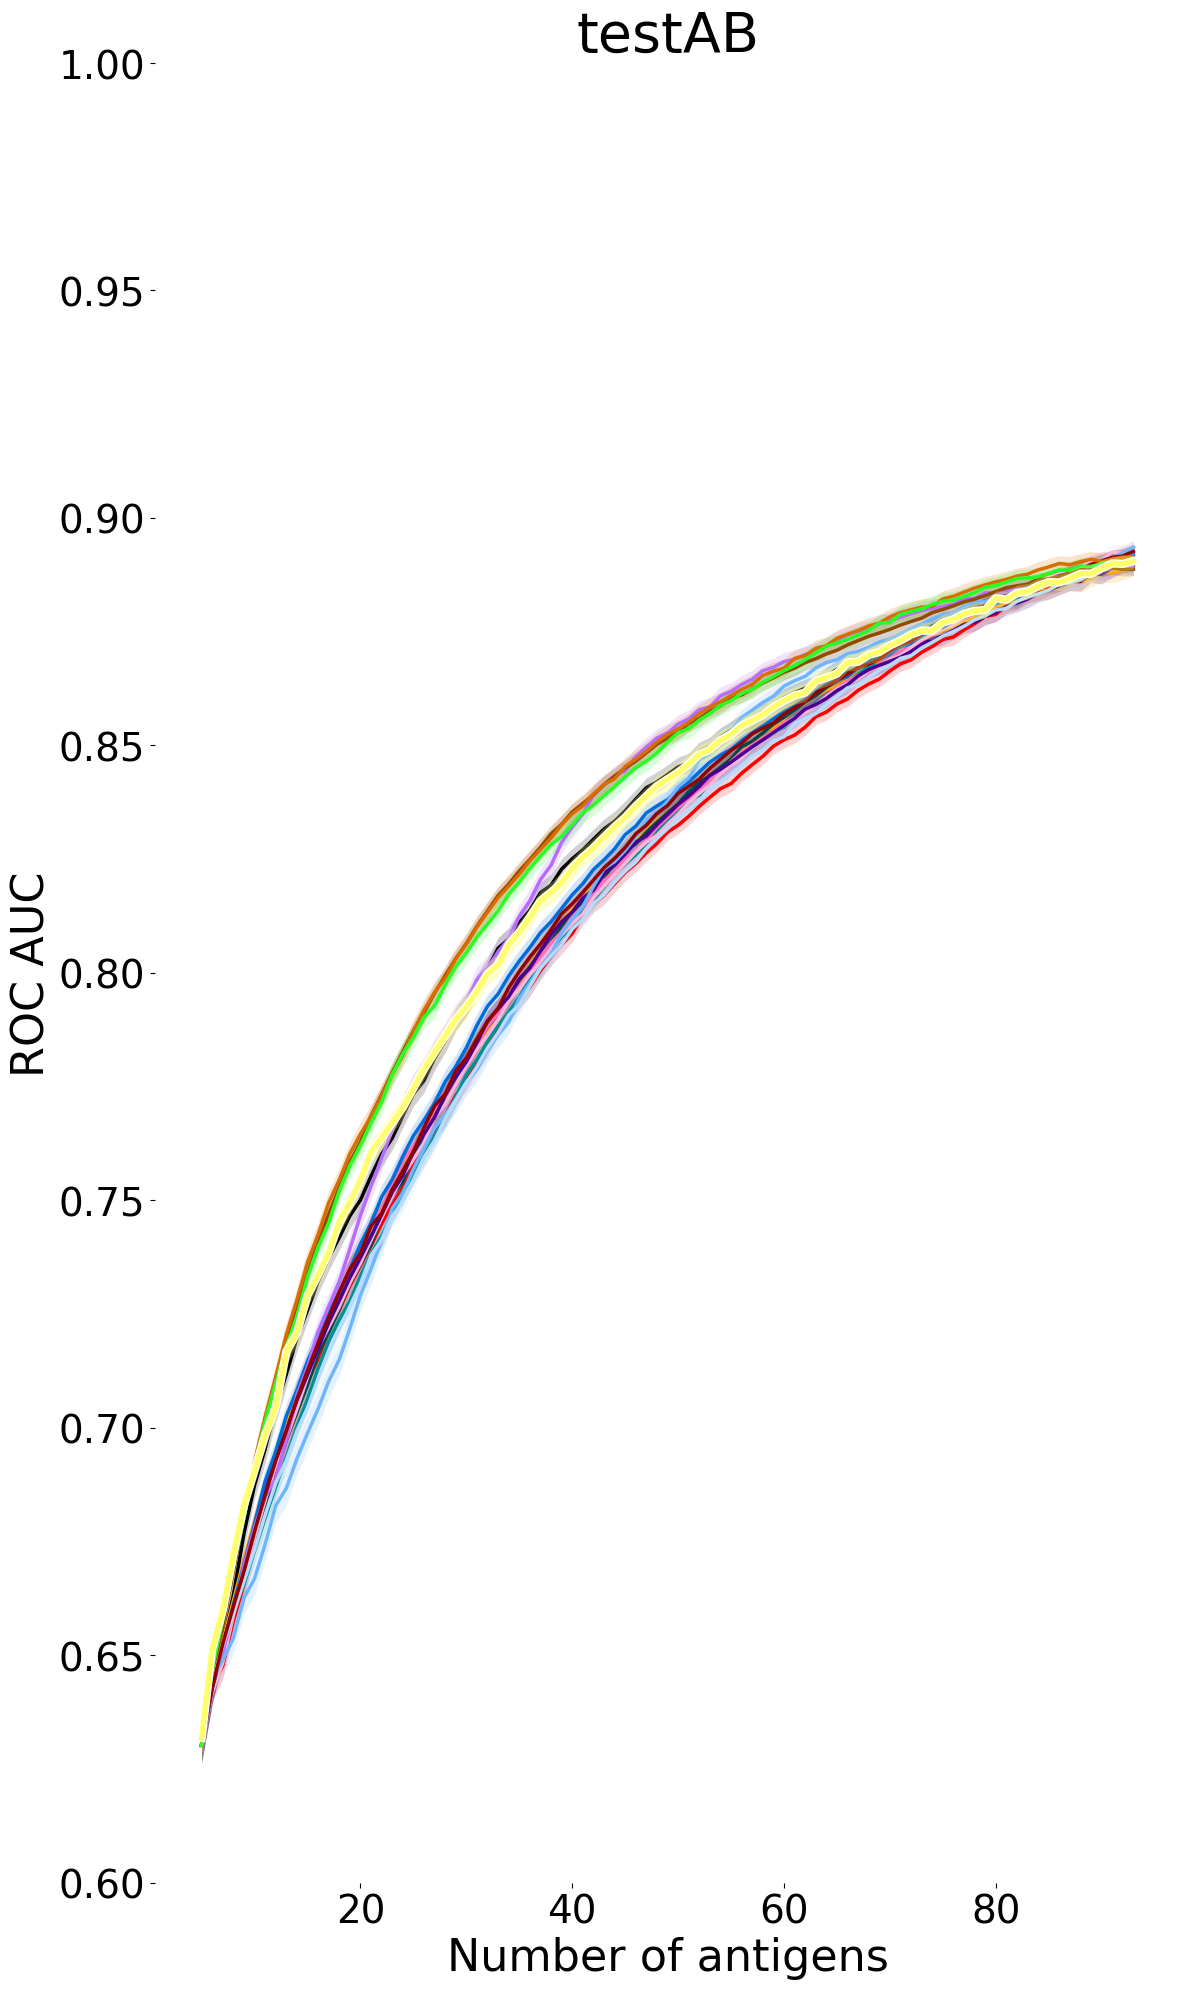

Saved pooled plot: ../results3/graphs/roc_auc_vs_ags_testAG_all_noises_pooled.png


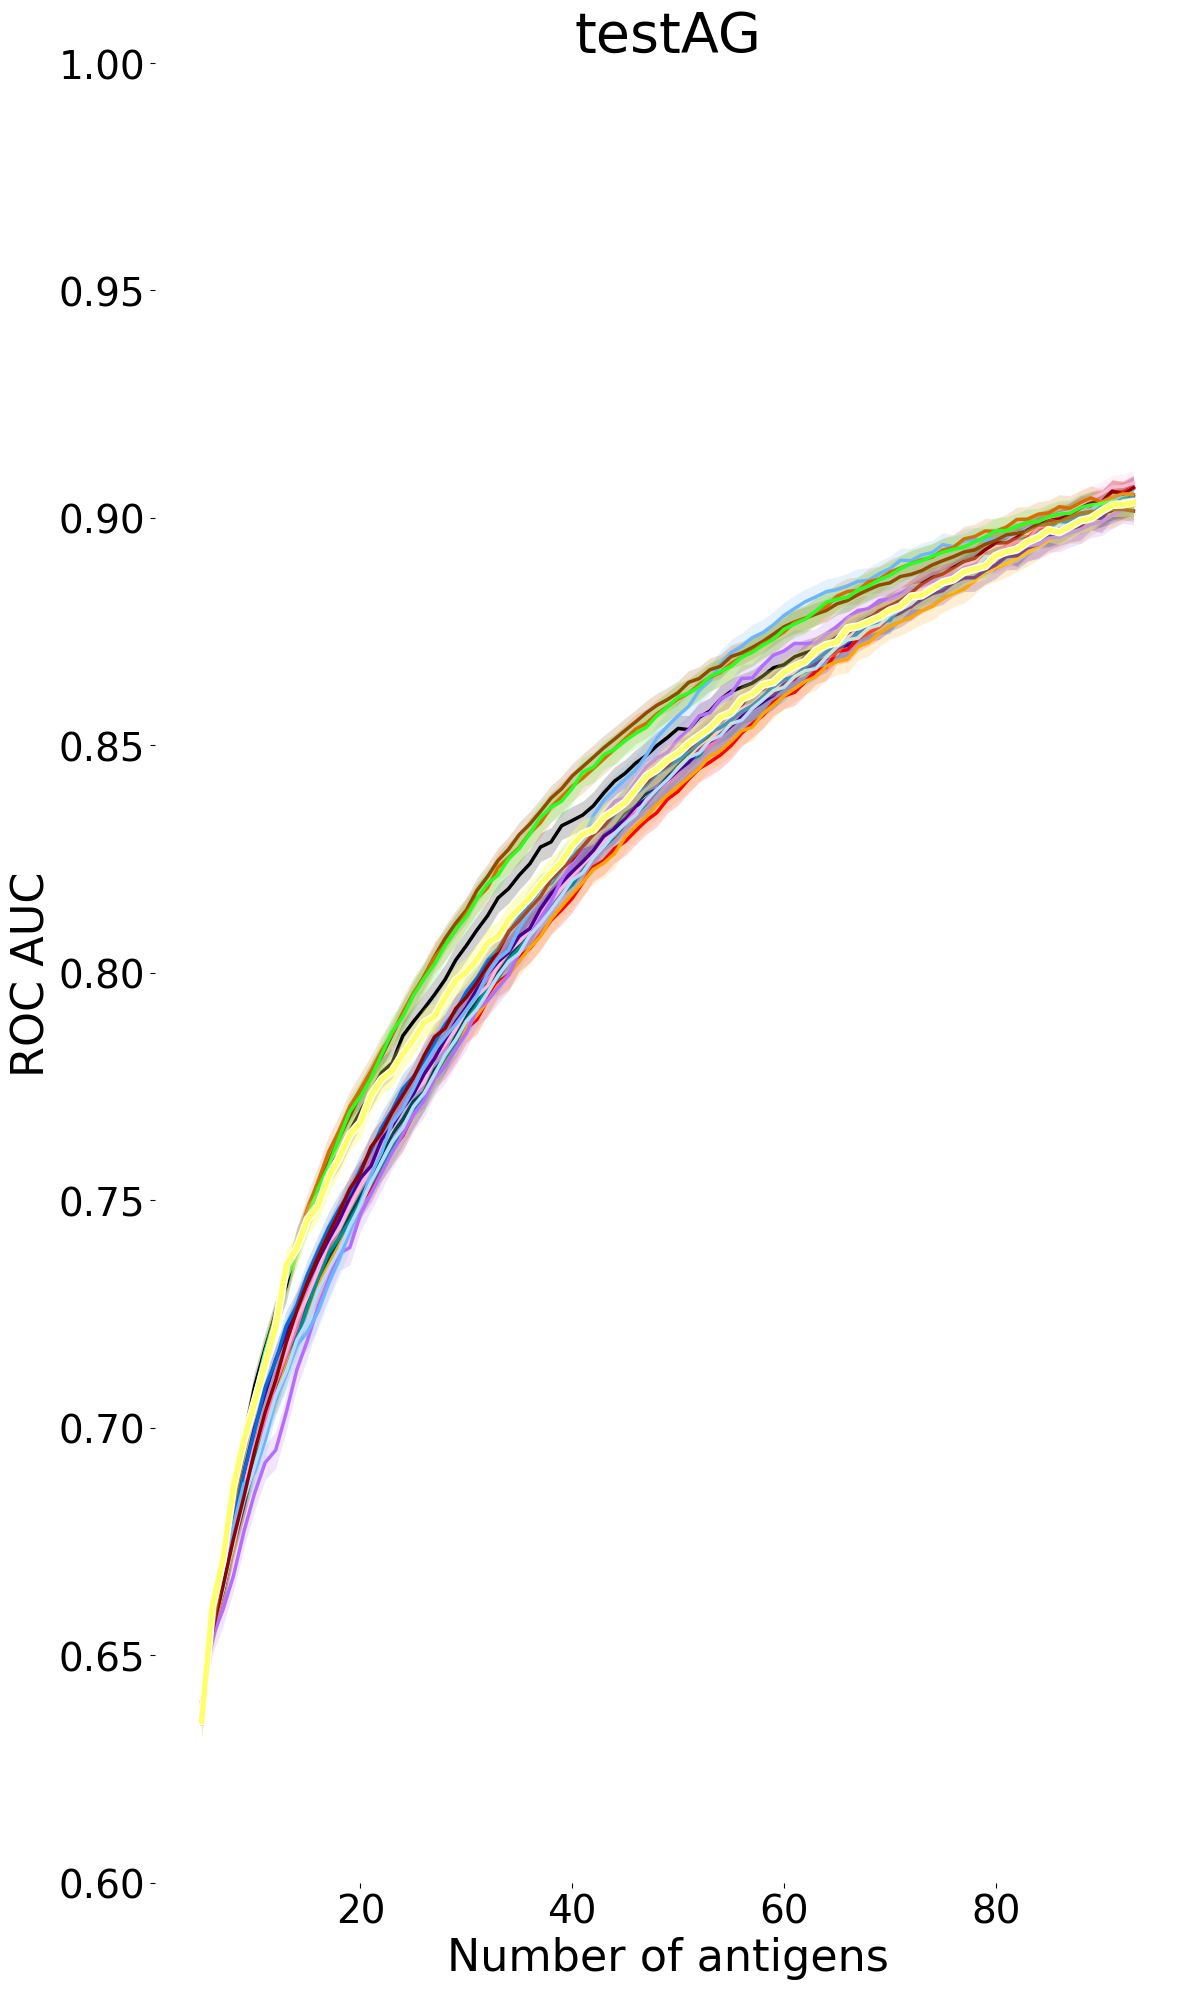

Saved pooled plot: ../results3/graphs/roc_auc_vs_ags_test_all_noises_pooled.png


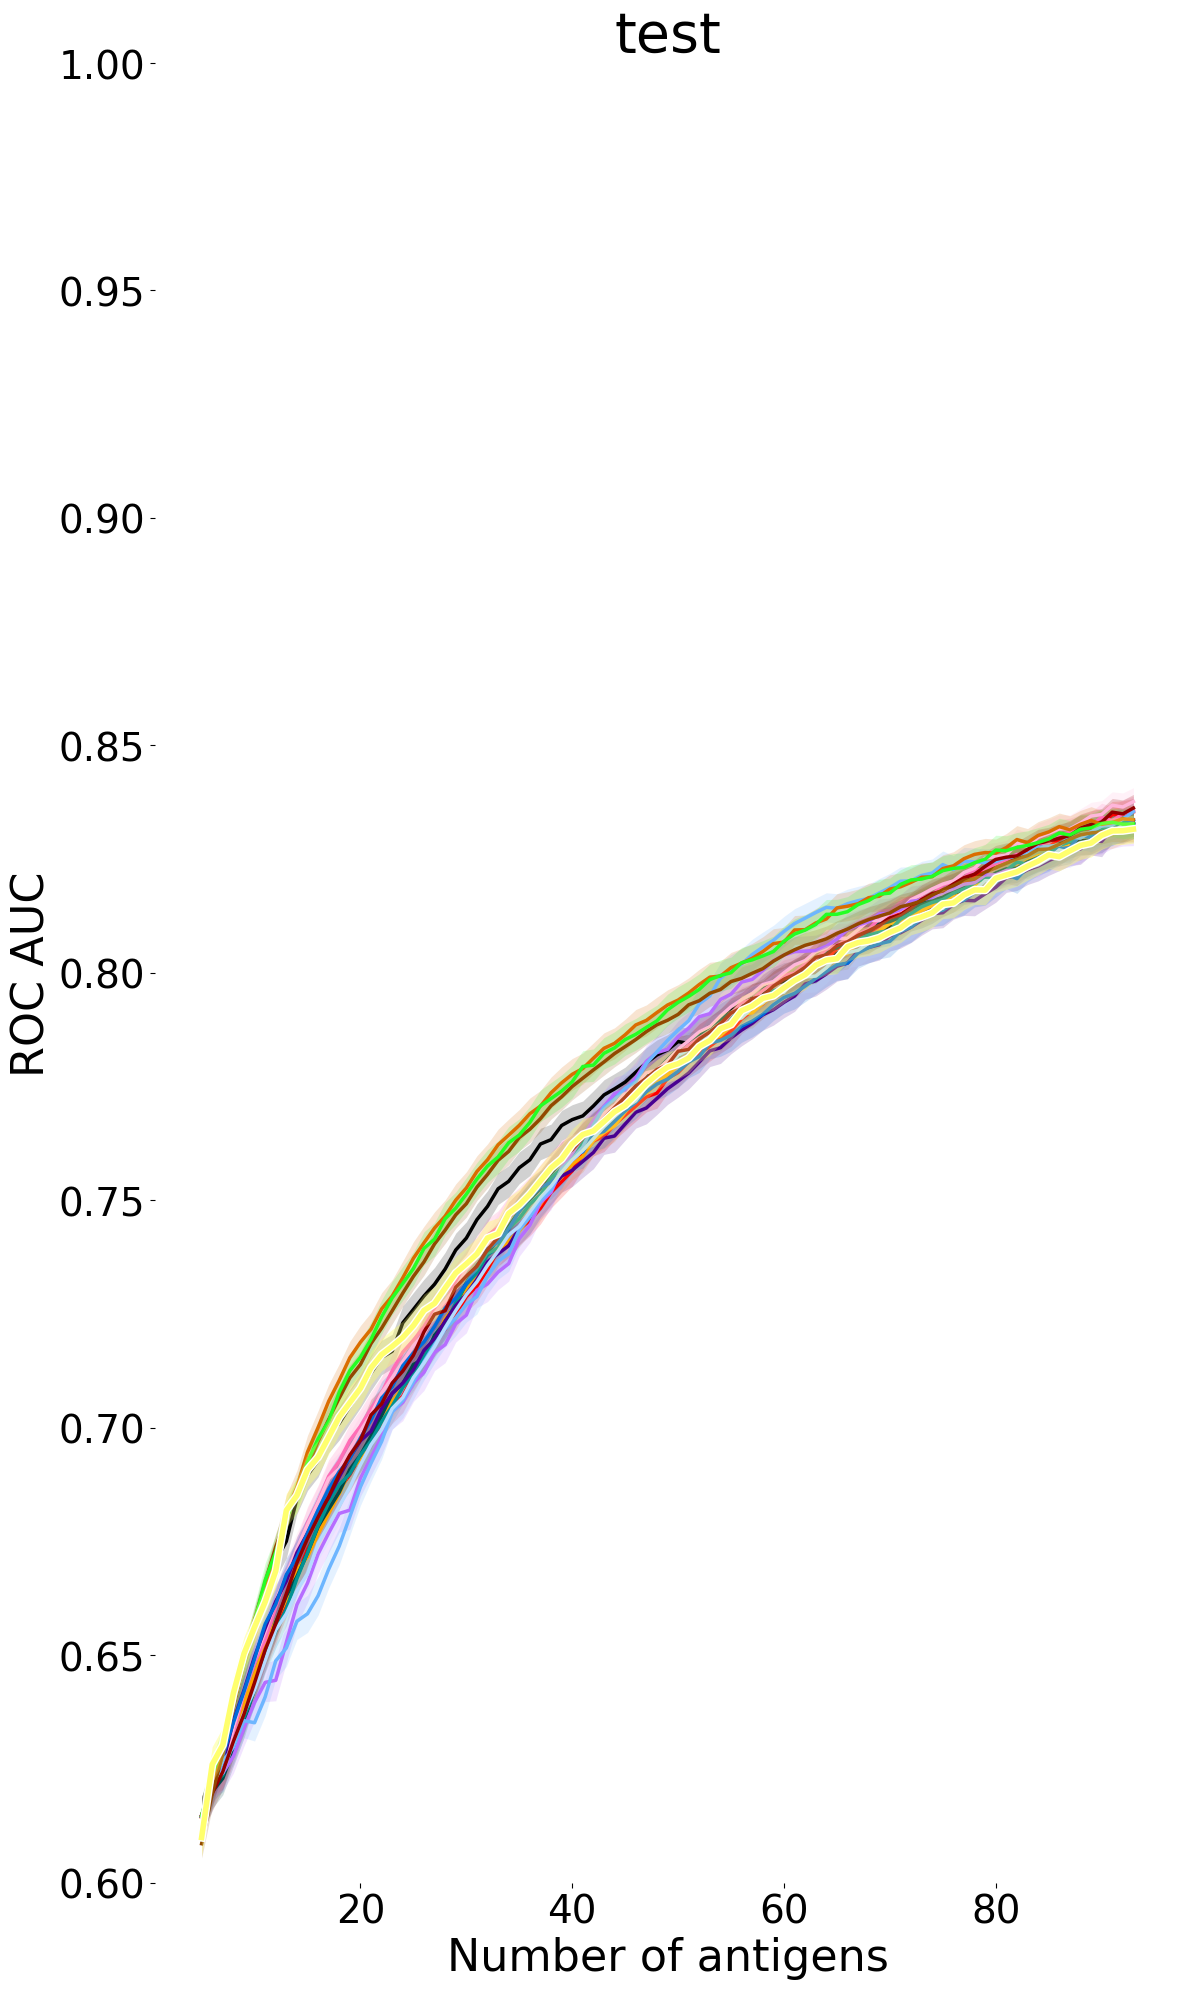

In [5]:
import numpy as np
import matplotlib.patheffects as pe


all_dfs = [df.assign(noise=int(noise)) for noise, df in df_full.items() if not df.empty]
if not all_dfs:
    print("No data collected across noises — skipping pooled plots")
else:
    df_all_noises = pd.concat(all_dfs, ignore_index=True)

    for test in tests:
        col = f"roc_aucs_{test}"
        if col not in df_all_noises.columns:
            print(f"Column {col} not in pooled dataframe — skipping")
            continue

        plt.figure(figsize=(12, 20))
        ax = plt.gca()
        plotted_any = False
        means_export = {}

        
        pool_methods = sorted(df_all_noises['method'].unique())

        
        highlight_method = 'random'
        highlight_buffer = None  

        for method in pool_methods:
            df_m = df_all_noises[df_all_noises['method'] == method]
            if df_m.empty:
                continue

            grouped = df_m.groupby("ags_number")[col]
            mean_series = grouped.mean().sort_index()
            if mean_series.empty:
                continue
            std_series = grouped.std().sort_index().reindex(mean_series.index).fillna(0.0)
            count_series = grouped.count().sort_index().reindex(mean_series.index).fillna(0).astype(int)

            
            sem = std_series / np.sqrt(count_series.replace(0, np.nan))
            ci95 = 1.96 * sem
            ribbon_low = (mean_series - ci95).values
            ribbon_high = (mean_series + ci95).values
            ribbon_low = np.where(np.isnan(ribbon_low), mean_series.values, ribbon_low)
            ribbon_high = np.where(np.isnan(ribbon_high), mean_series.values, ribbon_high)
            ribbon_low = np.clip(ribbon_low, 0.0, 1.0)
            ribbon_high = np.clip(ribbon_high, 0.0, 1.0)

            x = mean_series.index.astype(int).values
            y = mean_series.values

            color = method_colors.get(method, "#000000")
            label = method_labels.get(method, method)


            ax.plot(x, y, label=label, color=color, linewidth=2.5, marker=None, linestyle='-')
            if len(x) == len(ribbon_low) == len(ribbon_high):
                ax.fill_between(x, ribbon_low, ribbon_high, color=color, alpha=0.18, linewidth=0)

            means_export[method] = pd.Series(data=y, index=x)
            plotted_any = True

            
            if method == highlight_method:
                highlight_buffer = {
                    "x": x, "y": y,
                    "low": ribbon_low, "high": ribbon_high,
                    "color": color, "label": label
                }

        if not plotted_any:
            print(f"No pooled data for test={test}")
            plt.close()
            continue

        
        if highlight_buffer is not None:
            x_h = highlight_buffer["x"]
            y_h = highlight_buffer["y"]
            low_h = highlight_buffer["low"]
            high_h = highlight_buffer["high"]
            color_h = highlight_buffer["color"]
            label_h = highlight_buffer["label"]

            
            ax.plot(
                x_h, y_h,
                linewidth=4.0, color=color_h, zorder=20,
                label=label_h + " (highlight)",
                path_effects=[pe.Stroke(linewidth=6, foreground='white'), pe.Normal()]
            )
            
            ax.fill_between(x_h, low_h, high_h, color=color_h, alpha=0.28, linewidth=0, zorder=19)

        k = 2
        ax.set_xlabel("Number of antigens", fontsize=16*k)
        ax.set_ylabel("ROC AUC", fontsize=16*k)
        ax.set_title(f"{test}", fontsize=20*k)
        ax.tick_params(axis='both', which='major', labelsize=14*k)
        ax.set_frame_on(False)
        ax.set_ylim(0.6, 1.0)
        

        out_png = os.path.join(out_base, f"roc_auc_vs_ags_{test}_all_noises_pooled.png")
        plt.tight_layout()
        plt.savefig(out_png, dpi=150)
        print(f"Saved pooled plot: {out_png}")
        plt.show()
        plt.close()

        df_means = pd.DataFrame(means_export).sort_index()
        out_csv = os.path.join(out_base, "means", f"mean_rocaucs_{test}_all_noises_pooled.csv")
        df_means.to_csv(out_csv, index_label="ags_number")


In [6]:
df_mean = pd.read_csv(os.path.join(out_base, "means", f'mean_rocaucs_test_all_noises_pooled.csv'))

q1 = list(df_mean.random)

In [7]:
df_mean

ts = []
for n in range(len(q1)):
    q = q1[n]
    rs = []
    for m in methods_lst:
        q2 = df_mean[m]
        mask = q2.gt(q)
        if mask.any():
            first_label = mask.idxmax() 
            first_pos = mask.values.argmax()
            
            rs.append(first_pos)
       
    ts.append(int(n - min(rs)))
    


In [8]:
n = int(np.argmax(ts))


q = q1[n]
rs = []
for m in methods_lst:
    q2 = df_mean[m]
    mask = q2.gt(q)
    if mask.any():
        first_label = mask.idxmax()       
        first_pos = mask.values.argmax()  
        
        rs.append(int(first_pos))

ts.append(int(n - min(rs)))


print(methods_lst[np.argmin(rs)])
rr = df_mean[int(n-max(ts)):int(n+1)].ags_number
print(min(rr), max(rr))

hamming_min
63 74
